Load an image.

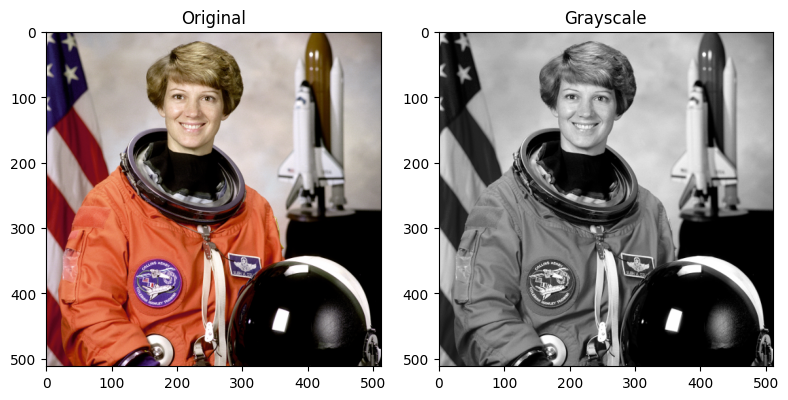

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data
from skimage.color import rgb2gray

original = data.astronaut()
grayscale = rgb2gray(original)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
ax = axes.ravel()

ax[0].imshow(original)
ax[0].set_title("Original")
ax[1].imshow(grayscale, cmap=plt.cm.gray)
ax[1].set_title("Grayscale")

fig.tight_layout()
plt.show()

# Load the image
img = grayscale
img_array = np.array(img)

### Understanding Convolution through Code

In this example, we'll visually explore how **2D convolution** works with an image. We'll use a simple **edge detection filter** to highlight sharp changes in the image, like lines or edges.

1. **Original Image**: We'll first load a grayscale image.
2. **Kernel (Filter)**: A small 3x3 grid that helps us identify edges. The numbers inside the kernel indicate how much emphasis to place on each part of the image.
   - Negative numbers look for darker regions, while the positive number looks for bright regions.
3. **Convolution**: The kernel slides over the entire image, checking for edges by multiplying its values with the image pixels.

The code below loads an image, applies the convolution, and shows:
- The original image
- The image after applying the edge detection filter
- A visual representation of the filter (kernel)

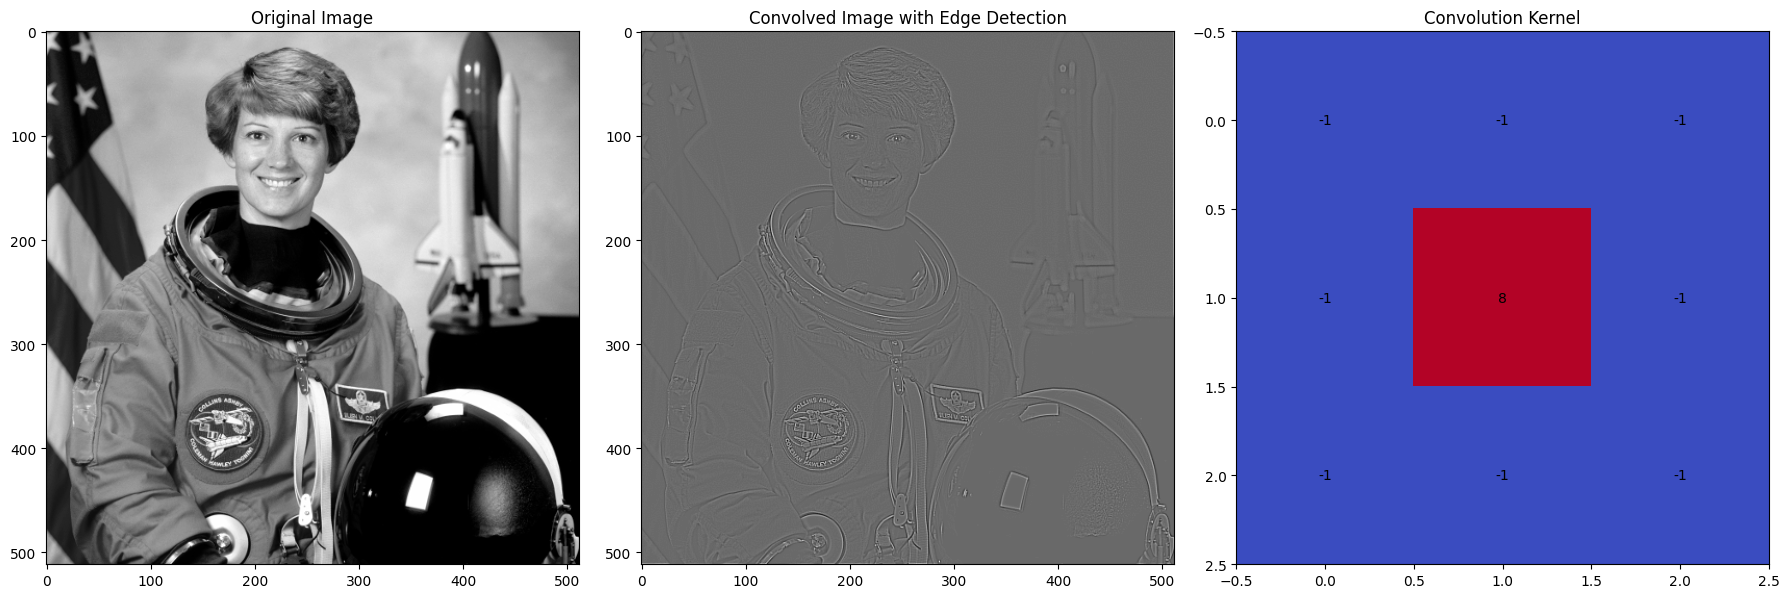

In [ ]:
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
from PIL import Image

# Define a simple edge detection filter
kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]])

# Apply the 2D convolution
convolved_image = convolve2d(img_array, kernel, mode='same')

# Plot original image, convolved image, and kernel
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Increase the number of subplots to 3

# Plot original image
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original Image")

# Plot convolved image
axes[1].imshow(convolved_image, cmap='gray')
axes[1].set_title("Convolved Image with Edge Detection")

# Plot kernel visualization
kernel_img = axes[2].imshow(kernel, cmap='coolwarm', interpolation='none')
axes[2].set_title("Convolution Kernel")
# Annotate the kernel values on the plot
for i in range(kernel.shape[0]):
    for j in range(kernel.shape[1]):
        axes[2].text(j, i, str(kernel[i, j]), ha='center', va='center', color='black')

plt.tight_layout()
plt.show()


### Understanding Stride in Convolution

In this cell, we will explore how changing the **stride** affects the output of convolution. The **stride** controls how much we move the kernel over the image:

- **Stride 1**: The kernel moves one pixel at a time. This results in a detailed output, as the convolution examines every possible position.
- **Stride 2 (or higher)**: The kernel skips some pixels, which leads to a smaller output image and faster computation. This is known as **downsampling**. The resulting image is less detailed but faster to compute.

The function below applies convolution with a given stride and compares the results.


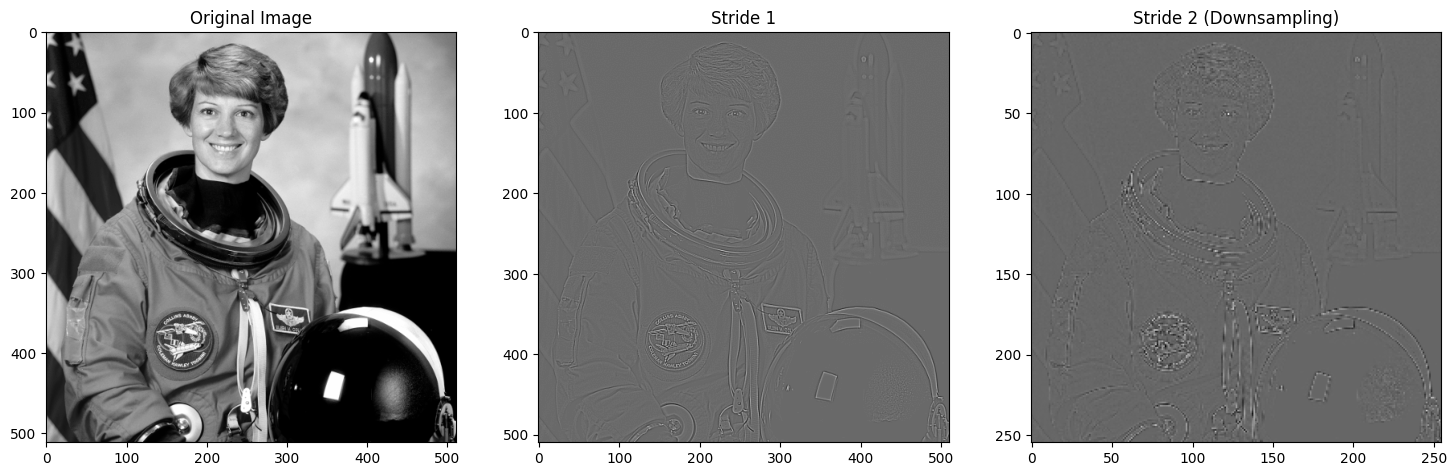

In [ ]:
# Function to demonstrate stride
def convolve_with_stride(image, kernel, stride):
    output = convolve2d(image, kernel, mode='valid')[::stride, ::stride]
    return output

# Stride 1 vs Stride 2 convolution
stride_1 = convolve_with_stride(img_array, kernel, stride=1)
stride_2 = convolve_with_stride(img_array, kernel, stride=2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original Image")
axes[1].imshow(stride_1, cmap='gray')
axes[1].set_title("Stride 1")
axes[2].imshow(stride_2, cmap='gray')
axes[2].set_title("Stride 2 (Downsampling)")
plt.show()


### Max Pooling: Simplifying the Image

In this step, we will explore **max pooling**, a technique used in neural networks to reduce the size of an image while preserving important features.

#### What is Max Pooling?
Max pooling divides the image into small regions (here, 2x2 blocks) and keeps only the largest value from each block. This reduces the resolution of the image but keeps the most important information. It's like summarizing an area by its strongest feature.

#### Why Use Max Pooling?
1. **Downsampling**: Reduces the size of the data, making the network faster and less prone to overfitting.
2. **Feature Preservation**: Even with reduced resolution, important features (like edges) remain in the image.

In the code below, we apply a **2x2 max pooling** operation to a grayscale image, which reduces the size of the image by half.


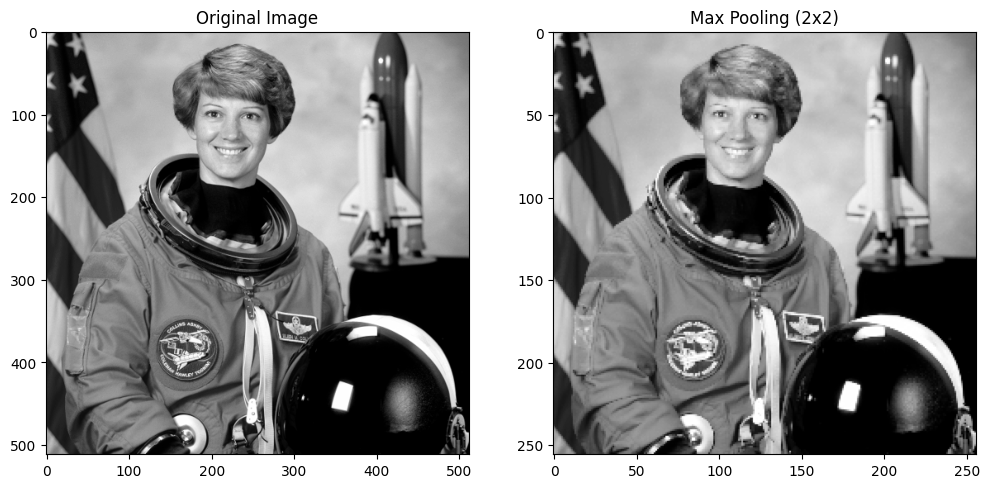

In [ ]:
import torch
import torch.nn.functional as F

# Convert image to torch tensor
img_tensor = torch.tensor(img_array).unsqueeze(0).unsqueeze(0).float()

# Apply 2x2 max pooling
max_pool_2x2 = F.max_pool2d(img_tensor, kernel_size=2, stride=2)

# Visualize the original and pooled images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original Image")
axes[1].imshow(max_pool_2x2.squeeze().numpy(), cmap='gray')
axes[1].set_title("Max Pooling (2x2)")
plt.show()


### Upsampling with Transposed Convolution

In this step, we explore **upsampling**, a technique used to increase the size of an image by reversing the downsampling process. Specifically, we use **transposed convolution** to double the resolution of the image.

#### What is Transposed Convolution (Upsampling)?
Transposed convolution (also called **deconvolution**) is a process that expands an image by adding extra pixels, essentially reversing the effect of convolution or max pooling. This helps in situations where you need to bring the image back to a higher resolution, such as in image generation or segmentation tasks.

#### Why Use Transposed Convolution?
1. **Restoring Resolution**: After downsampling (like max pooling), we often need to increase the resolution to get an image closer to its original size.
2. **Maintaining Key Features**: Unlike simple resizing, transposed convolution is more intelligent in restoring features, as it considers learned patterns from the data.

In the code below, we apply **transposed convolution** to the previously pooled image, doubling its resolution.


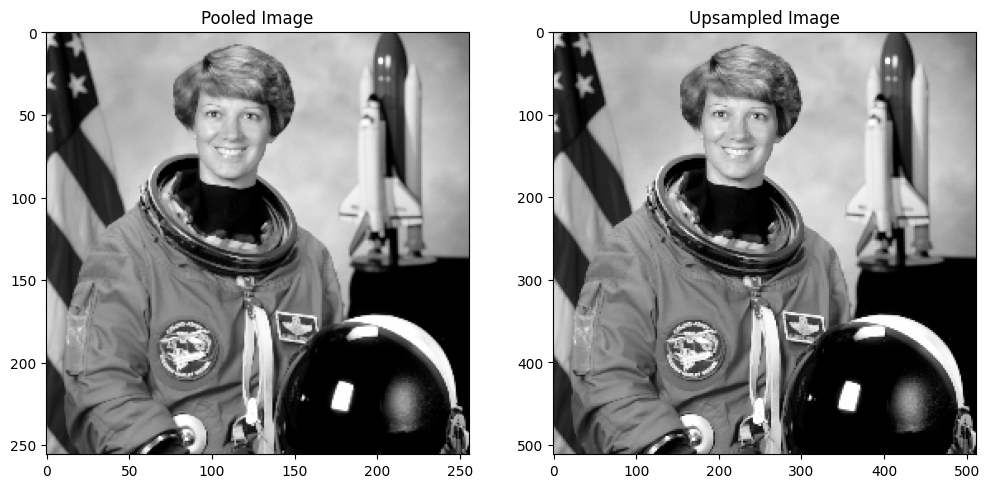

In [ ]:
# Perform upsampling (transposed convolution) to double the resolution
upsampled = F.conv_transpose2d(max_pool_2x2, torch.ones((1, 1, 2, 2)), stride=2)

# Visualize upsampled image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(max_pool_2x2.squeeze().numpy(), cmap='gray')
axes[0].set_title("Pooled Image")
axes[1].imshow(upsampled.squeeze().numpy(), cmap='gray')
axes[1].set_title("Upsampled Image")
plt.show()


### Visualizing Convolutional Kernels

In this step, we will visualize various commonly used **convolutional kernels** (or filters) as heatmaps. Each kernel serves a specific purpose in image processing, such as edge detection, blurring, sharpening, etc.

#### What are Convolutional Kernels?
A **convolutional kernel** is a small matrix used to modify an image by highlighting specific features, such as edges or corners, or by applying effects like blurring. These kernels are applied to the image using convolution to extract relevant information.

#### Kernels Used:
- **Sobel X & Y**: Detect horizontal and vertical edges in an image.
- **Prewitt X & Y**: Another set of edge detection filters.
- **Laplacian**: Detects edges by measuring the second derivative of the image.
- **Box Blur**: Averages pixel values to create a blurring effect.
- **Gaussian Blur**: Applies a smoother blur by weighting nearby pixels.
- **Sharpen**: Emphasizes edges to make the image look crisper.
- **Emboss**: Creates a 3D effect by highlighting edges.
- **Identity**: Leaves the image unchanged.

In the code below, we visualize each kernel using a **heatmap**, where the colors represent the values in the kernel matrix. This helps in understanding the structure of each filter.


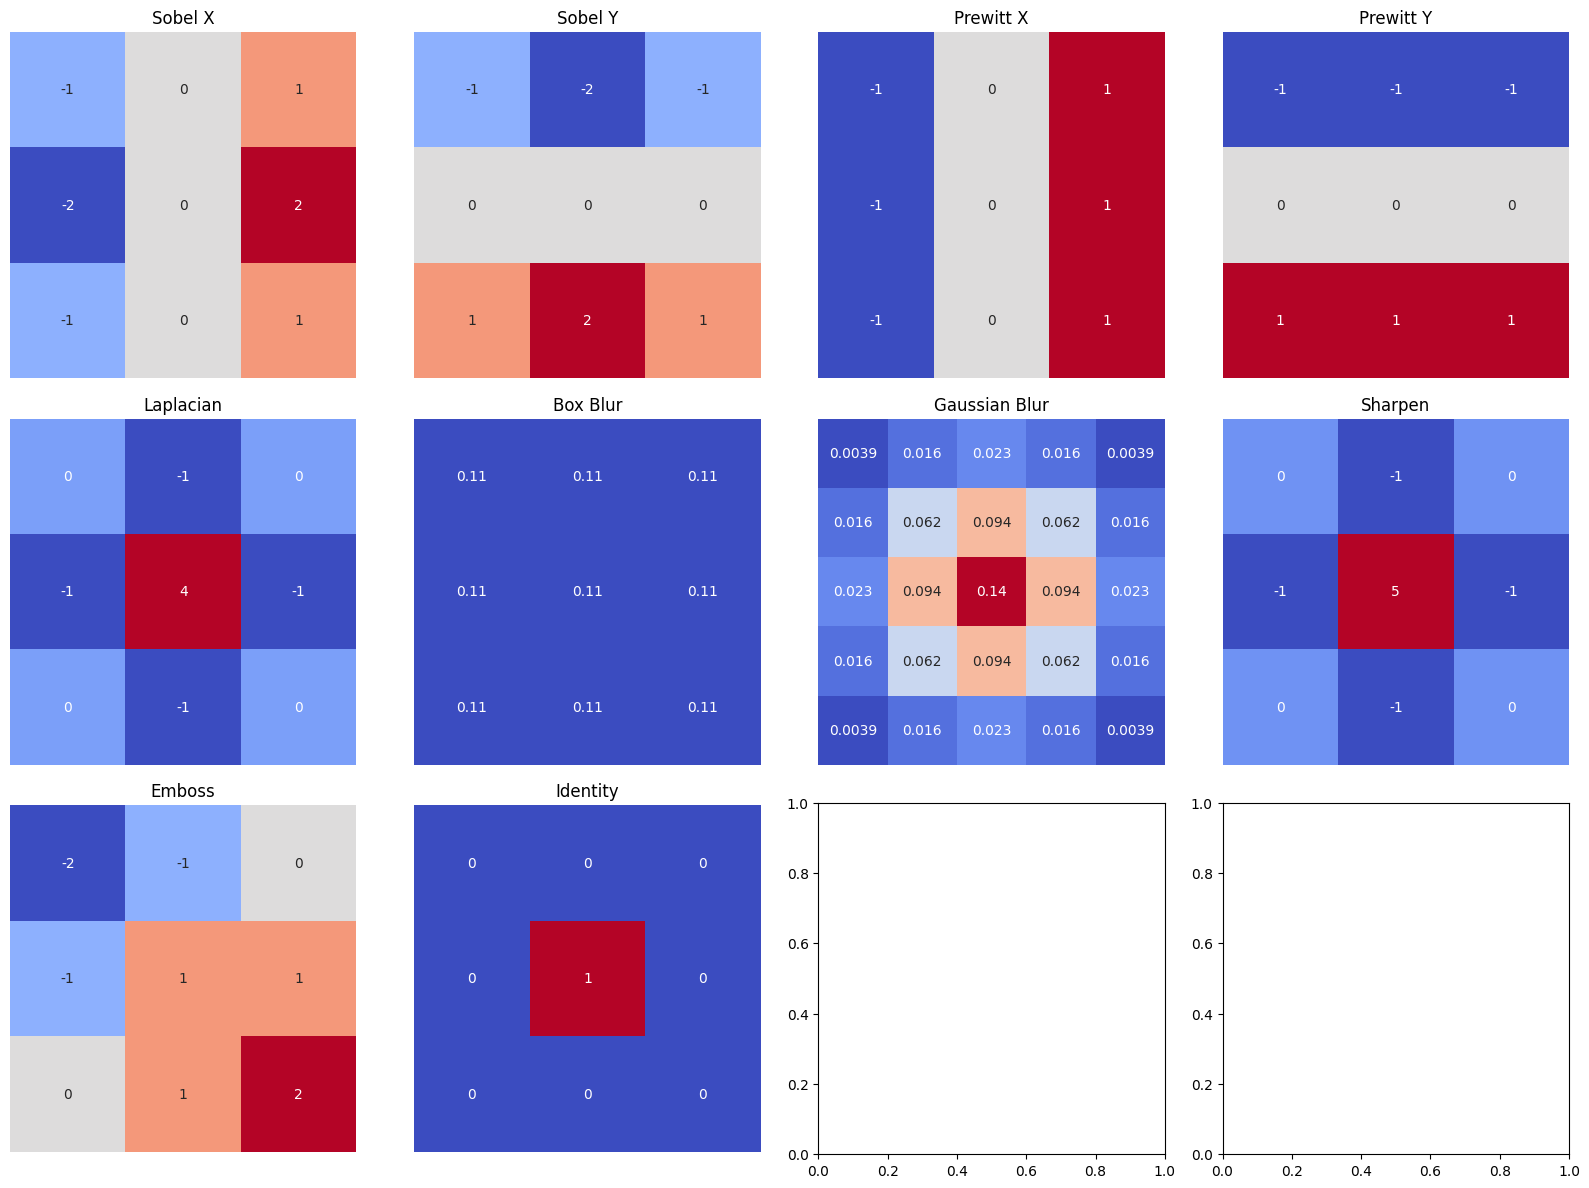

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define all the kernels
kernels = {
    "Sobel X": np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]]),

    "Sobel Y": np.array([[-1, -2, -1],
                         [ 0,  0,  0],
                         [ 1,  2,  1]]),

    "Prewitt X": np.array([[-1, 0, 1],
                           [-1, 0, 1],
                           [-1, 0, 1]]),

    "Prewitt Y": np.array([[-1, -1, -1],
                           [ 0,  0,  0],
                           [ 1,  1,  1]]),

    "Laplacian": np.array([[ 0, -1,  0],
                           [-1,  4, -1],
                           [ 0, -1,  0]]),

    "Box Blur": np.ones((3, 3)) / 9,

    "Gaussian Blur": np.array([[ 1,  4,  6,  4,  1],
                               [ 4, 16, 24, 16,  4],
                               [ 6, 24, 36, 24,  6],
                               [ 4, 16, 24, 16,  4],
                               [ 1,  4,  6,  4,  1]]) / 256,

    "Sharpen": np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]]),

    "Emboss": np.array([[-2, -1,  0],
                        [-1,  1,  1],
                         [ 0,  1,  2]]),

    "Identity": np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]])
}

# Set up the plot grid
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()  # Flatten axes array for easy indexing

# Plot each kernel as a heatmap
for idx, (kernel_name, kernel_matrix) in enumerate(kernels.items()):
    sns.heatmap(kernel_matrix, annot=True, cmap='coolwarm', cbar=False, square=True, ax=axes[idx])
    axes[idx].set_title(kernel_name)
    axes[idx].axis('off')  # Remove axis ticks for better readability

# Adjust layout
plt.tight_layout()
plt.show()


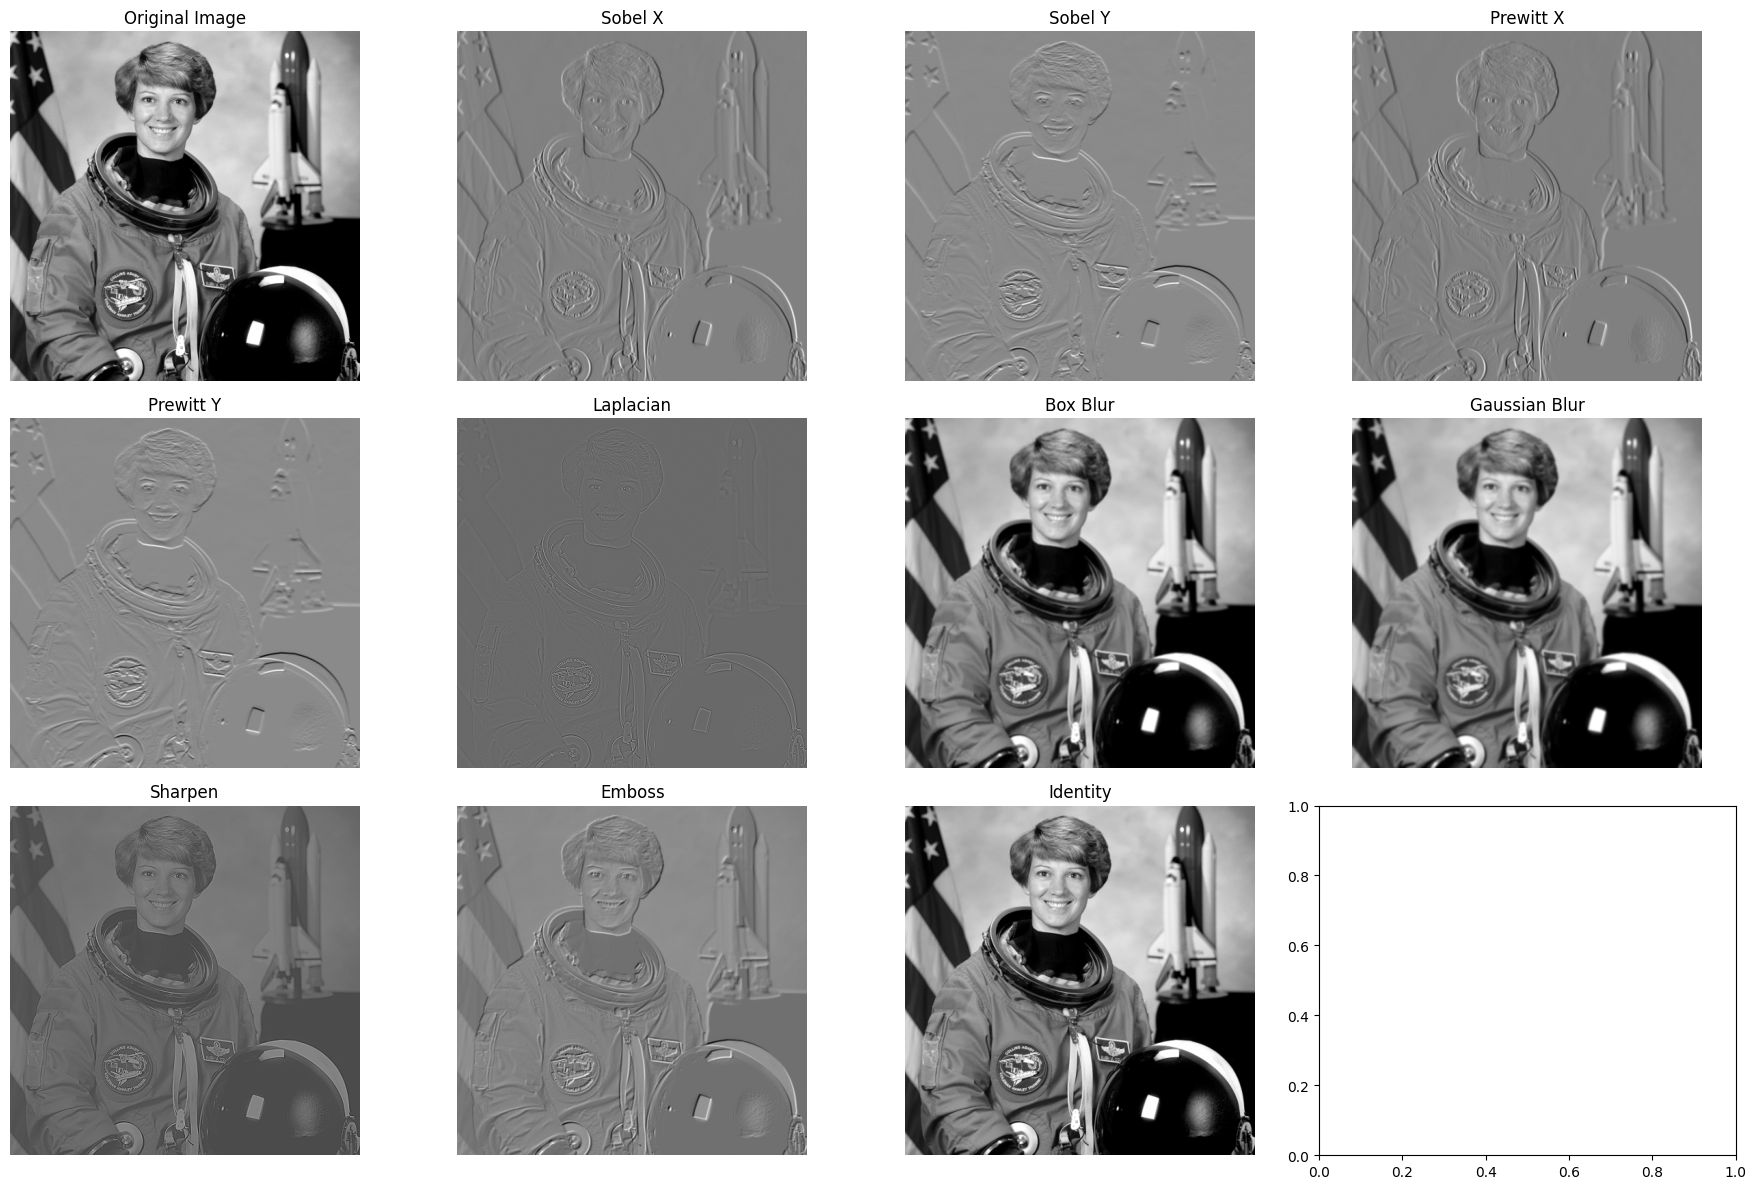

In [ ]:
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Define all the kernels
kernels = {
    "Sobel X": np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]]),

    "Sobel Y": np.array([[-1, -2, -1],
                         [ 0,  0,  0],
                         [ 1,  2,  1]]),

    "Prewitt X": np.array([[-1, 0, 1],
                           [-1, 0, 1],
                           [-1, 0, 1]]),

    "Prewitt Y": np.array([[-1, -1, -1],
                           [ 0,  0,  0],
                           [ 1,  1,  1]]),

    "Laplacian": np.array([[ 0, -1,  0],
                           [-1,  4, -1],
                           [ 0, -1,  0]]),

    "Box Blur": np.ones((3, 3)) / 9,

    "Gaussian Blur": np.array([[1,  6,  15,  20,  15,  6,  1],
                            [6, 36,  90, 120,  90, 36,  6],
                            [15, 90, 225, 300, 225, 90, 15],
                            [20,120, 300, 400, 300,120, 20],
                            [15, 90, 225, 300, 225, 90, 15],
                            [6, 36,  90, 120,  90, 36,  6],
                            [1,  6,  15,  20,  15,  6,  1]]) / 4096,


    "Sharpen": np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]]),

    "Emboss": np.array([[-2, -1,  0],
                        [-1,  1,  1],
                         [ 0,  1,  2]]),

    "Identity": np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]])
}

# Set up the plot grid for the original image and the convolved results
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.ravel()  # Flatten axes array for easy indexing

# Plot the original image
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

# Apply each kernel to the image and plot the result
for idx, (kernel_name, kernel_matrix) in enumerate(kernels.items(), start=1):
    # Apply the convolution using the kernel
    convolved_image = convolve2d(img_array, kernel_matrix, mode='same', boundary='symm')

    # Plot the convolved image
    axes[idx].imshow(convolved_image, cmap='gray')
    axes[idx].set_title(kernel_name)
    axes[idx].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


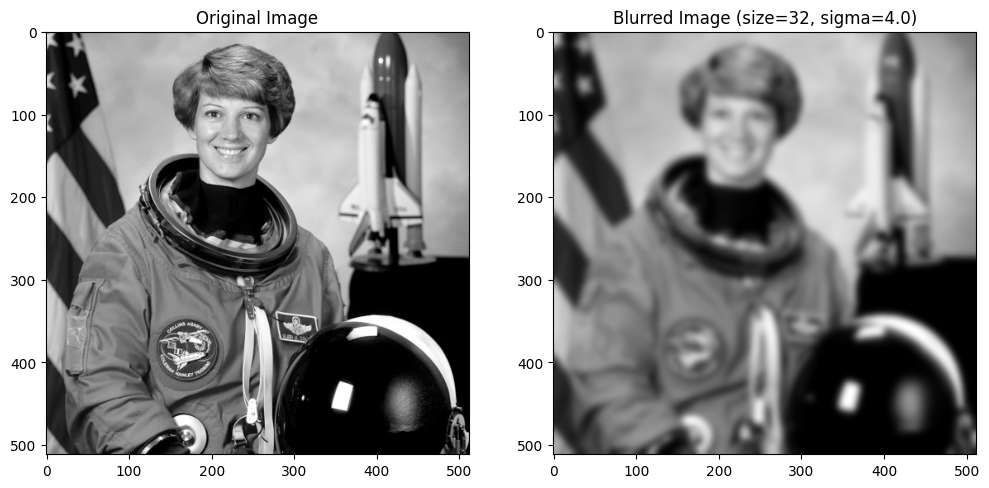

In [ ]:
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
from PIL import Image

# Function to create a 2D Gaussian kernel
def gaussian_kernel(size, sigma=1):
    """
    Create a 2D Gaussian kernel.

    Parameters:
    size (int): The size of the kernel (size x size).
    sigma (float): Standard deviation of the Gaussian distribution.

    Returns:
    np.ndarray: Gaussian kernel of shape (size, size).
    """
    # Create a grid of (x, y) coordinates
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)

    # Calculate the 2D Gaussian kernel using the formula
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))

    # Normalize the kernel so that the sum of all elements is 1
    kernel = kernel / np.sum(kernel)

    return kernel

# Create a Gaussian kernel with a variable size and sigma
size = 32  # You can change the size
sigma = 4.0  # You can change sigma
gaussian_k = gaussian_kernel(size, sigma)  # Rename the variable to avoid conflict

# Apply the 2D convolution with Gaussian blur
blurred_image = convolve2d(img_array, gaussian_k, mode='same', boundary='symm')

# Plot the original and blurred image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original Image")
axes[1].imshow(blurred_image, cmap='gray')
axes[1].set_title(f"Blurred Image (size={size}, sigma={sigma})")
plt.show()


### Visualizing Feature Maps from Convolutional Layers

In this example, we'll create a **binary spiral image**, pass it through two convolutional layers, and visualize the **feature maps** produced at each stage. This helps us understand how convolutional neural networks (CNNs) extract features from an image.

#### Step-by-Step Process:

1. **Creating a Binary Spiral Image**:
   - We generate a binary image of a spiral shape using a mathematical formula. The image is a 64x64 grid where pixels are either 0 (black) or 1 (white), forming a spiral pattern.

2. **Convolutional Layers**:
   - We use two convolutional layers (`Conv2d`) to extract features from the input image. The number of **channels** (or feature maps) increases after each layer, allowing the network to capture more complex features.
     - **Conv1**: The first convolutional layer takes the input image (1 channel) and produces 2 feature maps.
     - **Conv2**: The second convolutional layer increases the number of feature maps to 16, allowing deeper feature extraction.

3. **Visualizing Feature Maps**:
   - After each convolutional layer, we visualize the feature maps. Feature maps show how different patterns, edges, or textures are highlighted by the convolution.


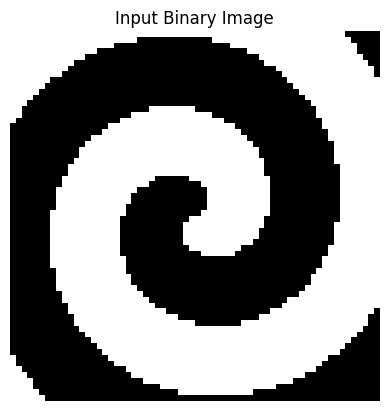

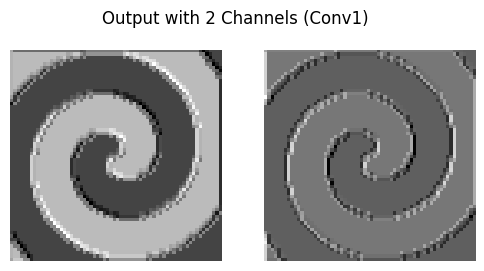

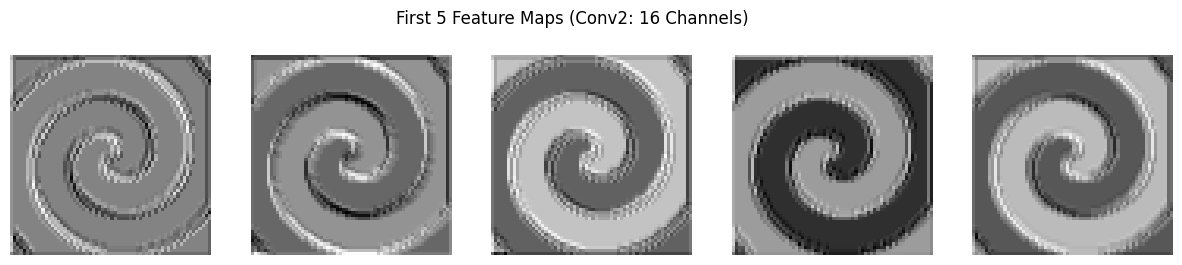

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Function to visualize feature maps
def visualize_feature_maps(tensor, title=""):
    n_maps = tensor.shape[1]  # Number of channels
    fig, axes = plt.subplots(1, n_maps, figsize=(n_maps * 3, 3))
    for i in range(n_maps):
        axes[i].imshow(tensor[0, i].detach().numpy(), cmap='gray')
        axes[i].axis('off')
    plt.suptitle(title)
    plt.show()

# Step 1: Create a binary image with a spiral shape
def create_spiral_image(size=64):
    x = np.linspace(-2, 2, size)
    y = np.linspace(-2, 2, size)
    X, Y = np.meshgrid(x, y)

    # Create a simple spiral formula
    Z = np.sin(4 * np.sqrt(X**2 + Y**2) + np.arctan2(Y, X))

    # Normalize the values to be in the range [0, 1]
    spiral = (Z > 0).astype(float)  # Binary spiral shape
    return spiral

# Create a spiral image of size 64x64
spiral_image = create_spiral_image(size=64)

# Convert the spiral image to a PyTorch tensor with 32 channels
input_channels = 1
input_tensor = torch.tensor(spiral_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0).repeat(1, input_channels, 1, 1)

# Visualize the binary input image
plt.imshow(input_tensor[0, 0].numpy(), cmap='gray')
plt.title("Input Binary Image")
plt.axis('off')
plt.show()

# Define the convolutional layers with customizable channels
conv1_in_channels = 1  # Input channel for conv1
conv1_out_channels = 2  # Output channels for conv1

conv2_in_channels = conv1_out_channels  # Input channels for conv2 matches conv1's output
conv2_out_channels = 16  # Output channels for conv2 (deep feature maps)

# Apply the Conv2d layers
conv1 = nn.Conv2d(in_channels=conv1_in_channels, out_channels=conv1_out_channels, kernel_size=3, stride=1, padding=1)
output_tensor1 = conv1(input_tensor)

# Visualize the output feature maps for the first convolution
visualize_feature_maps(output_tensor1, title=f"Output with {conv1_out_channels} Channels (Conv1)")

# Apply another Conv2d layer with more channels
conv2 = nn.Conv2d(in_channels=conv2_in_channels, out_channels=conv2_out_channels, kernel_size=3, stride=1, padding=1)
output_tensor2 = conv2(output_tensor1)

# Visualize a subset of the feature maps from the second convolution
# Here, we only display a few channels (for example, the first 5 out of 128)
visualize_feature_maps(output_tensor2[:, :5], title=f"First 5 Feature Maps (Conv2: {conv2_out_channels} Channels)")


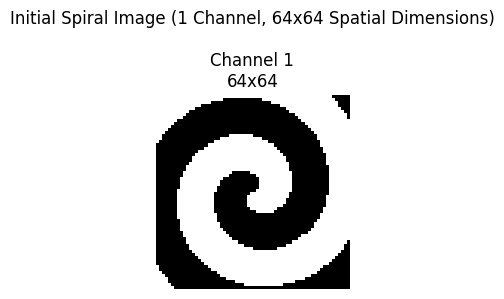

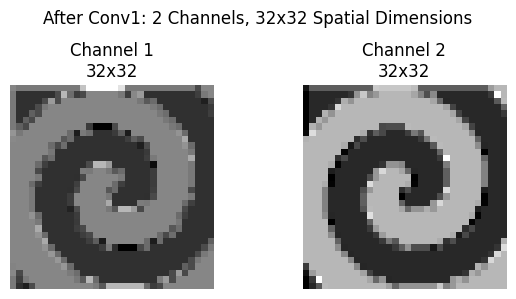

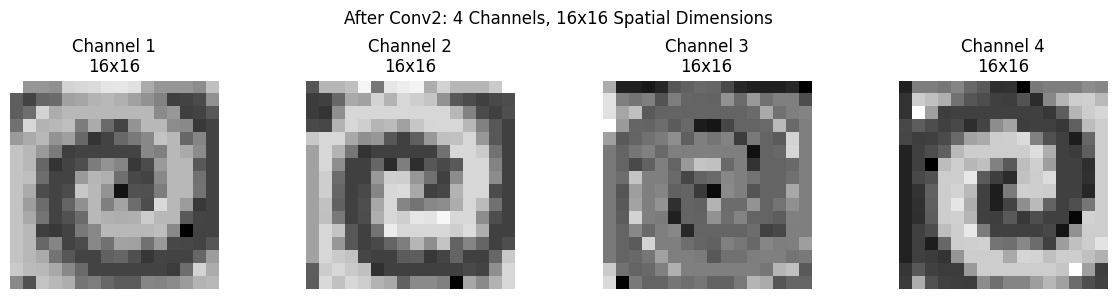

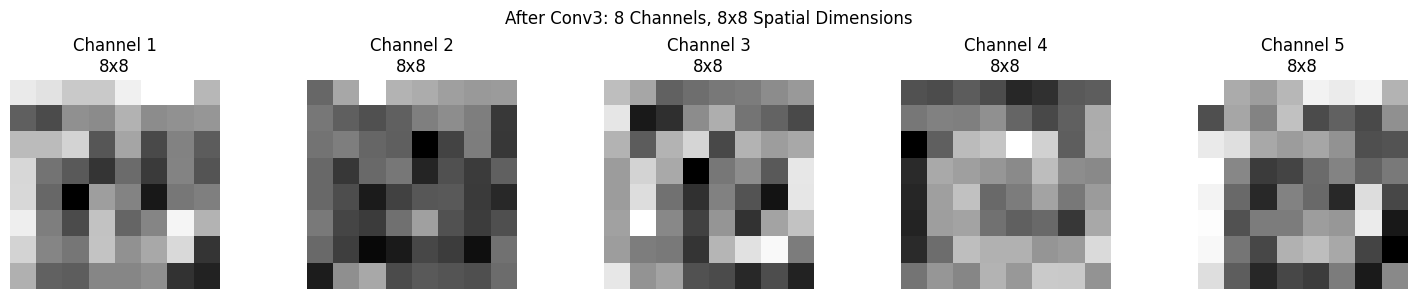

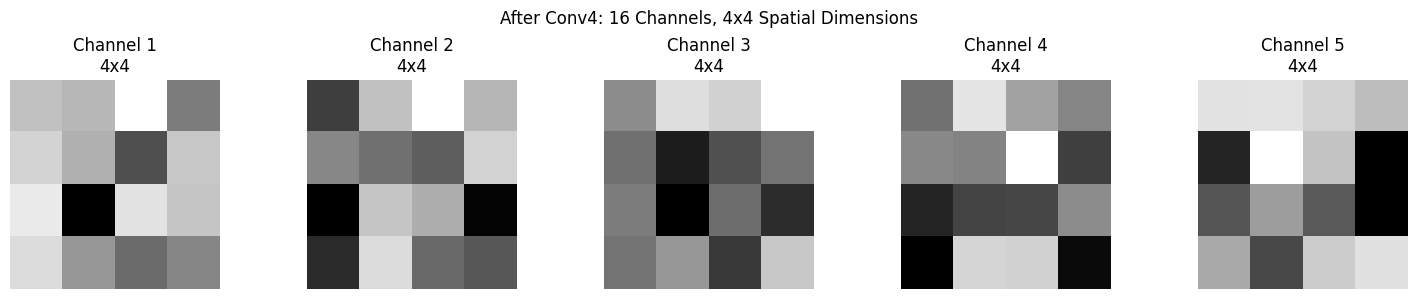

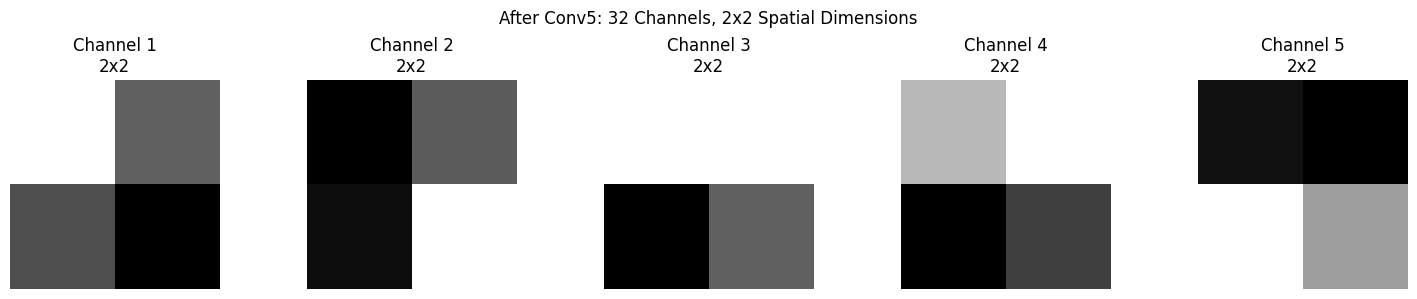

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Function to visualize feature maps
def visualize_feature_maps(tensor, title=""):
    n_maps = tensor.shape[1]  # Number of channels
    n_maps_to_show = min(n_maps, 5)  # Show up to 5 feature maps for clarity
    spatial_dim = tensor.shape[2]  # Height/width of the feature map

    fig, axes = plt.subplots(1, n_maps_to_show, figsize=(3 * n_maps_to_show, 3))

    # If there's only one feature map, axes is not a list
    if n_maps_to_show == 1:
        axes = [axes]

    for i in range(n_maps_to_show):
        feature_map = tensor[0, i].detach().cpu().numpy()
        axes[i].imshow(feature_map, cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f"Channel {i+1}\n{spatial_dim}x{spatial_dim}")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Step 1: Create a binary image with a spiral shape
def create_spiral_image(size=64):
    x = np.linspace(-2, 2, size)
    y = np.linspace(-2, 2, size)
    X, Y = np.meshgrid(x, y)

    # Create a simple spiral formula
    Z = np.sin(4 * np.sqrt(X**2 + Y**2) + np.arctan2(Y, X))

    # Normalize the values to be in the range [0, 1]
    spiral = (Z > 0).astype(float)  # Binary spiral shape
    return spiral

# Create a spiral image of size 64x64
spiral_image = create_spiral_image(size=64)

# Convert the spiral image to a PyTorch tensor with 1 channel initially
input_channels = 1
input_tensor = torch.tensor(spiral_image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# Visualize the initial spiral input
visualize_feature_maps(input_tensor, title=f"Initial Spiral Image (1 Channel, 64x64 Spatial Dimensions)")

# Step 2: Define a series of Conv2d layers to halve the spatial dimensions while doubling the channels
conv_layers = []
current_channels = input_channels
current_height, current_width = 64, 64

# Define the target number of layers to increase channels to 32 and halve spatial dimensions
# Channels: 1 → 2 → 4 → 8 → 16 → 32
# Spatial Dimensions: 64 → 32 → 16 → 8 → 4 → 2
for i in range(5):
    out_channels = current_channels * 2
    conv = nn.Conv2d(in_channels=current_channels, out_channels=out_channels, kernel_size=3, stride=2, padding=1)
    conv_layers.append(conv)
    current_channels = out_channels
    current_height //= 2
    current_width //= 2

# Sequentially apply the convolutional layers and visualize
current_tensor = input_tensor
for idx, conv in enumerate(conv_layers):
    current_tensor = conv(current_tensor)
    # Determine the title based on the current number of channels and spatial dimensions
    title = f"After Conv{idx+1}: {current_tensor.shape[1]} Channels, {current_tensor.shape[2]}x{current_tensor.shape[3]} Spatial Dimensions"
    visualize_feature_maps(current_tensor, title=title)

# # Step 3: Visualize the final output
# # Since it has many channels, plot the first 5 feature maps
# final_image = current_tensor[0, 0].detach().cpu().numpy()
# plt.imshow(final_image, cmap='gray')
# plt.title(f"Final Output: {current_tensor.shape[1]} Channels, {current_tensor.shape[2]}x{current_tensor.shape[3]} Spatial Dimensions")
# plt.axis('off')
# plt.show()
